# Process atrium data

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Init


In [22]:
import os
import sys
import random
from tabulate import tabulate
import itertools
from tqdm import tqdm
import pprint
import textwrap
import traceback
import spacy            
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict
from pathlib import Path
from joblib import Parallel, delayed
from flair.embeddings import TransformerWordEmbeddings
from flair.models import SequenceTagger
from flair.trainers import ModelTrainer
from flair.data import Corpus
from flair.datasets import DataLoader, CONLL_03
from flair.datasets import ColumnCorpus
from flair.visual.training_curves import Plotter
from flair.data import Sentence
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download


from logging import getLogger
import logging

from logging.handlers import RotatingFileHandler
import sys

log_file = Path.home() / "logs" / f"{__name__}.log"
def setup_logger(log_file=log_file, max_bytes=10*1024*1024, backup_count=5):
    """
    Sets up a logger that logs INFO and above to stdout and everything to a
    rolling file.

    Args:
        log_file: The name of the log file (default: "out.log").
        max_bytes: The maximum size of the log file before it rolls over
            (default: 10MB).
        backup_count: The number of backup log files to keep (default: 5).
    """
    # Create a logger
    logger = logging.getLogger(__name__)  # Or use a specific name if you prefer
    logger.setLevel(logging.DEBUG)  # Set the lowest level to be handled

    # Create a formatter
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s [%(name)s:%(lineno)d]')

    # Create a rolling file handler (all levels)
    file_handler = RotatingFileHandler(log_file,
                                       maxBytes=max_bytes,
                                       backupCount=backup_count)
    file_handler.setLevel(logging.DEBUG)  # Log all levels to the file
    file_handler.setFormatter(formatter)

    # Create a handler for stdout (INFO and above)
    stdout_handler = logging.StreamHandler(sys.stdout)
    stdout_handler.setLevel(logging.INFO)
    stdout_handler.setFormatter(formatter)

    # Add the handlers to the logger
    logger.handlers.clear()
    logger.addHandler(stdout_handler)
    logger.addHandler(file_handler)

    return logger

from dotenv import dotenv_values
env = dotenv_values(Path.home() / ".env")
NL = "\n"
TAB = "\t"

project_dir = Path("/usr/local/ilsp-nlp/experiments/atrium-speech-based-ie-app/")
data_dir = project_dir / "data"


## Context sheet sentences


In [23]:
context_sheet_sentences_file = data_dir / "context_sheet_sentences.txt"
context_sheet_sentences = list()
with open(context_sheet_sentences_file) as inf:    
    for line in inf:
        if line.startswith("#") or not line.strip():
            continue        
        context_sheet_sentences.append(line.strip())



### Visualizations

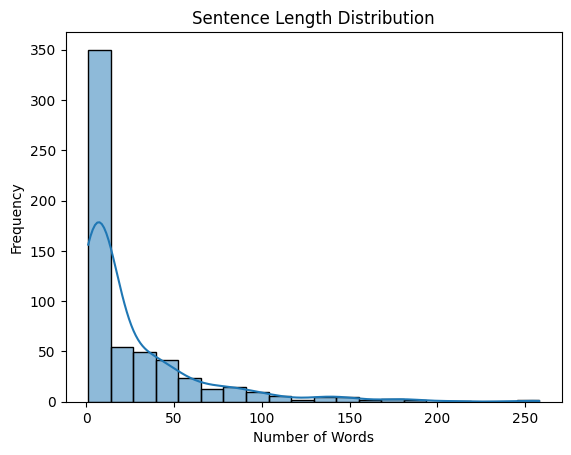

In [24]:
import seaborn as sns

# Calculate sentence lengths
sentence_lengths = [len(sentence.split()) for sentence in context_sheet_sentences]

# Plot histogram
sns.histplot(sentence_lengths, bins=20, kde=True)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


In [25]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Get the list of stopwords for the desired language (e.g., English)
stop_words = set(stopwords.words('english'))

# Remove stopwords from context_sheet_sentences
filtered_sentences = [
    " ".join([word for word in sentence.split() if word.lower() not in stop_words])
    for sentence in context_sheet_sentences
]

# Example: Print the first few filtered sentences
print(filtered_sentences[:5])


['Digging form North South, 20cm depth, big scale tools(Pickaxe) Modern Finds(tile) mouse hole south eastern wall. Shrink 5*5m2 2*2m2 north west side. Finish 20cm depth South 2.5*5m2 side. Finish 40cm depth North 2.5*5m2 side.', '80-100cm, animal holes Northeast Northwest corner, condition made soil soft loosen. 100-120cm, finding become less, volumn become large. 120-155cm, finding come less large bottom, soil became softer losse, came many yellow caly CBM.', 'Yellow Clay came ar bottom context, charcoal came out, change context C405, also came aome holes(6~7)', 'Yellow caly come small hole west east side, middle north side, come lots pottery CBM, soil color dark brown C404.', 'pottery Late Neolithic Phase 2 maybe soak water long time. Little quantitiy late Neolithic 1. Concretion bottom side pottery. 1. burned water? 2.Dump pit ceramic.']


[nltk_data] Downloading package stopwords to /usr/local/ilsp-
[nltk_data]     nlp/resources/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


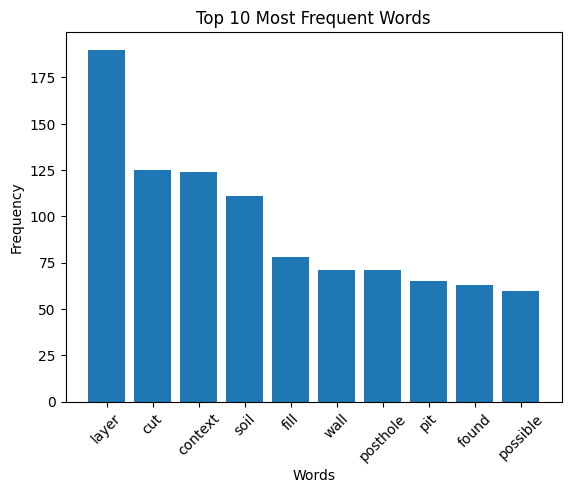

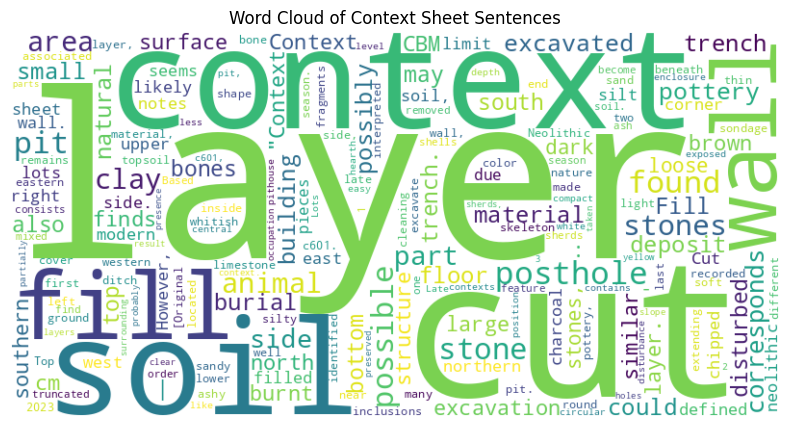

In [28]:

from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Count word frequencies
word_counts = Counter(" ".join(filtered_sentences).split())

# Bar chart for top 10 words
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# Word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Context Sheet Sentences")
plt.show()



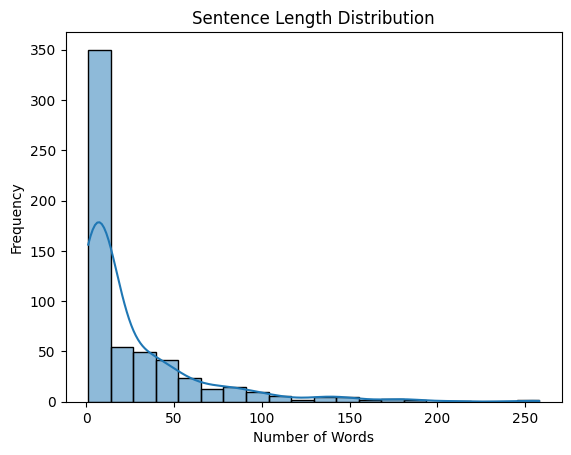

In [29]:
import seaborn as sns

# Calculate sentence lengths
sentence_lengths = [len(sentence.split()) for sentence in context_sheet_sentences]

# Plot histogram
sns.histplot(sentence_lengths, bins=20, kde=True)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## Convert json files to IOB

In [ ]:
nlp = spacy.blank("el")
iob_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_iob"

# -----------------------------------------------------------------------------
# This loop processes each annotation JSON file in the NSK NER dataset.
# For each file:
#   - It checks the file's validity.
#   - Loads the JSON data and extracts text, sentences, tokens, and spans.
#   - Converts annotation data to offset and IOB formats.
#   - Applies sentence merging and formatting rules.
#   - Writes the processed data in IOB format to a new file.
#   - Maps original NSK labels to standardized labels using a mapping table.
# -----------------------------------------------------------------------------

for annot_file in annot_files:
    check_that_file_is_ok(annot_file)
    with open(annot_file) as json_data:
        # logger.debug(annot_file)
        iob_file = iob_dir / Path(annot_file.parent.name) / (annot_file.stem + ".iob")  
        iob_file.parent.mkdir(exist_ok=True)
        # logger.debug(iob_file)        
        d = json.load(json_data)[0]
        #logger.debug(f"{annot_file.stem} #sentences: {len(d['sentences'])}")
        #logger.debug(f"Examining {annot_file.name} -> {iob_file.name} #sentences: {len(d['sentences'])}")
        text = d["text"]
        sentences = d["sentences"]
        tokens = d["tokens"]
        spans=[]
        if "spans" in d:
            spans = d["spans"]
        
        sentence_offsets, token_offsets, entity_offsets = convert_to_offset_format(sentences, tokens, spans)
        iob_data = create_iob_data(text, sentence_offsets, token_offsets, entity_offsets)

        # Merge sentences ending with "Αρ." etc.
        iob_data = merge_sentences(iob_data)
        # Merge sentences ending with a small case and the next starting with a small case
        new_sentences = list()
        with open(iob_file, "w") as outf:
            for iob_sentence in iob_data:
                #logger.debug(f'# {iob_sentence["sentence_text"]}')
                # print(f'{iob_sentence["sentence_text"].strip()}')
                new_sentences.append(iob_sentence["sentence_text"])
                outf.write(f'# {iob_sentence["sentence_text"]}' + NL)
                for t in iob_sentence["tokens"]:
                    if (not t[0].strip()):
                        continue
                    label = t[1]
                    if "-" in label:
                        parts = label.split("-", 1)
                        #print(parts)
                        label = parts[0] + "-" + nsk_labels_df_dict[parts[1]]
                        #print(label)
                        #label = 
                    outf.write(TAB.join([t[0].strip(), label])+ NL)
                    #logger.debug(TAB.join([t[0].strip(), label]))
                outf.write(NL)
                #logger.debug("")               
logger.info(f"Processed len({len(list(annot_files))}) files.")


## Examine contents of IOB files

### Read content into a dict for each dataset. Dict is a list of dicts with entity, label, snippet


In [ ]:

iob_files = list(iob_dir.rglob("*.iob"))

n = 5  # number of tokens before and after the entity for the snippet

def extract_entities_from_file(iob_file, n=5):
    entities = []
    with open(iob_file, encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip() and not line.startswith("#")]
        tokens = []
        tags = []
        for line in lines:
            parts = line.split()
            if len(parts) < 2:
                continue
            tokens.append(parts[0])
            tags.append(parts[1])

        i = 0
        while i < len(tokens):
            tag = tags[i]
            if tag.startswith("B-"):
                label = tag[2:]
                entity_tokens = [tokens[i]]
                start = i
                i += 1
                while i < len(tokens) and tags[i] == f"I-{label}":
                    entity_tokens.append(tokens[i])
                    i += 1
                end = i  # exclusive
                snippet_start = max(0, start - n)
                snippet_end = min(len(tokens), end + n)
                snippet = " ".join(tokens[snippet_start:snippet_end])
                entities.append({
                    "text": " ".join(entity_tokens),
                    "label": label,
                    "snippet": snippet
                })
            else:
                i += 1
    return entities

# Group IOB files by their parent directory
parent_to_files = defaultdict(list)
for iob_file in iob_files:
    parent_to_files[iob_file.parent].append(iob_file)

# For each parent directory, build a list of entity dicts
entities_by_category = dict()
for parent, files in parent_to_files.items():
    all_entities = Parallel(n_jobs=5)(
        delayed(extract_entities_from_file)(iob_file, n) for iob_file in files
    )
    # Flatten the list of lists
    entities_by_category[parent] = [entity for sublist in all_entities for entity in sublist]

for parent, ents in entities_by_category.items():
    print(f"Collected {len(ents)} entities from directory: {parent}")

# Example: print(entities_by_category[list(entities_by_category.keys())[0]][:5])

### Visualize entity distribution

In [ ]:

## Label distribution

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# entities_by_category is a dict: {Path: [entity_dict, ...]}
for category, entities in entities_by_category.items():
    if not entities:
        continue
    df = pd.DataFrame(entities)
    df["label_en"] = df["label"]  # backup the original label column
    df["label"] = df["label"].map(lambda x: nsk_labels_reverse_dict.get(x, x))  # replace with NSK label
    plt.figure(figsize=(10, 5))    
    ax = sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
    plt.title(f"Label Distribution for {category.name}")
    plt.xlabel("Entity Label")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Average Entity Length (in tokens) per Label


In [ ]:
for category, entities in entities_by_category.items():
    if not entities:
        continue
    df = pd.DataFrame(entities)
    df["length"] = df["text"].apply(lambda x: len(x.split()))
    df["label_en"] = df["label"]  # backup the original label column
    df["label"] = df["label"].map(lambda x: nsk_labels_reverse_dict.get(x, x))  # replace with NSK label
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x="label", y="length", estimator="mean", order=df["label"].value_counts().index)
    plt.title(f"Average Entity Length (tokens) per Label for {category.name}")
    plt.xlabel("Entity Label")
    plt.ylabel("Average Length (tokens)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


### Top N Most Frequent Entity Texts per Label

In [ ]:
from collections import Counter

N = 5  # Top N entities to show
for category, entities in entities_by_category.items():
    if not entities:
        continue
    df = pd.DataFrame(entities)
    df["label_en"] = df["label"]  # backup the original label column
    df["label"] = df["label"].map(lambda x: nsk_labels_reverse_dict.get(x, x))  # replace with NSK label

    print(f"\nTop {N} entities per label for {category.name}:")
    for label in df["label"].unique():
        texts = df[df["label"] == label]["text"]
        most_common = Counter(texts).most_common(N)
        print(f"  {label}:")
        for text, count in most_common:
            print(f"    {text} ({count})")



### All Entity texts for selected entities

In [ ]:
# Print all entities for labels "Αντίδικοι - Όνομα" and "Αντίδικοι - Επώνυμο" for each category

target_labels = {"Αντίδικοι - Όνομα", "Αντίδικοι - Επώνυμο"}

for category, entities in entities_by_category.items():
    if not entities:
        continue
    df = pd.DataFrame(entities)
    # Translate label to Greek using nsk_labels_reverse_dict if needed
    df["label_gr"] = df["label"].map(lambda x: nsk_labels_reverse_dict.get(x, x))
    print(f"\nEntities for {category.name}:")
    for label in target_labels:
        ents = df[df["label_gr"] == label]["text"].tolist()
        print(f"  {label}:")
        for ent in ents:
            print(f"    {ent}")

### Label Distribution Across Categories


In [ ]:
# Build a DataFrame for all categories
all_rows = []
for category, entities in entities_by_category.items():
    for ent in entities:
        all_rows.append({"category": category.name, "label": ent["label"]})
df_all = pd.DataFrame(all_rows)
df_all["label_en"] = df_all["label"]  # backup the original label column
df_all["label"] = df_all["label"].map(lambda x: nsk_labels_reverse_dict.get(x, x))  # replace with NSK label

pivot = pd.pivot_table(df_all, index="category", columns="label", aggfunc=len, fill_value=0)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Entity Label Distribution Across Categories")
plt.ylabel("Category")
plt.xlabel("Entity Label")
plt.tight_layout()
plt.show()

### Entity Count per Document
 - See how many entities are annotated per document in each category. This can help spot annotation density or outliers.

In [ ]:
from collections import Counter

for category, files in parent_to_files.items():
    entity_counts = []
    for iob_file in files:
        entities = extract_entities_from_file(iob_file)
        entity_counts.append(len(entities))
    plt.figure(figsize=(8, 4))
    sns.histplot(entity_counts, bins=20, kde=True)
    plt.title(f"Entity Count per Document in {category.name}")
    plt.xlabel("Number of Entities")
    plt.ylabel("Number of Documents")
    plt.tight_layout()
    plt.show()

### Entity Length Distribution
- Visualize the distribution of entity lengths (in tokens) for each category.

In [ ]:
for category, entities in entities_by_category.items():
    if not entities:
        continue
    df = pd.DataFrame(entities)
    df["label_en"] = df["label"]  # backup the original label column
    df["label"] = df["label"].map(lambda x: nsk_labels_reverse_dict.get(x, x))  # replace with NSK label
    df["length"] = df["text"].apply(lambda x: len(x.split()))
    plt.figure(figsize=(8, 4))
    sns.histplot(df["length"], bins=15, kde=True)
    plt.title(f"Entity Length Distribution in {category.name}")
    plt.xlabel("Entity Length (tokens)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



### Co-occurrence Heatmap of Labels
- See which entity types tend to appear together in the same document.


In [ ]:
import numpy as np

for category, files in parent_to_files.items():
    label_sets = []
    for iob_file in files:
        entities = extract_entities_from_file(iob_file)
        labels = set(e["label"] for e in entities)
        label_sets.append(labels)
    all_labels = sorted({l for s in label_sets for l in s})
    cooc = np.zeros((len(all_labels), len(all_labels)), dtype=int)
    label_idx = {l: i for i, l in enumerate(all_labels)}
    for s in label_sets:
        for l1 in s:
            for l2 in s:
                cooc[label_idx[l1], label_idx[l2]] += 1
    plt.figure(figsize=(8, 6))
    sns.heatmap(cooc, xticklabels=all_labels, yticklabels=all_labels, cmap="Blues", annot=True, fmt="d")
    plt.title(f"Label Co-occurrence Heatmap in {category.name}")
    plt.xlabel("Label")
    plt.ylabel("Label")
    plt.tight_layout()
    plt.show()



### Pie Chart of Label Proportions
- A quick overview of label proportions in each category.

In [ ]:
for category, entities in entities_by_category.items():
    if not entities:
        continue
    df = pd.DataFrame(entities)
    label_counts = df["label"].value_counts()
    plt.figure(figsize=(8, 8))
    plt.pie(label_counts, labels=label_counts.index, autopct="%1.1f%%", startangle=140)
    plt.title(f"Label Proportions in {category.name}")
    plt.tight_layout()
    plt.show()


### A word cloud per label for each category


In [ ]:
from wordcloud import WordCloud

# for category, entities in entities_by_category.items():
#     if not entities:
#         continue
#     df = pd.DataFrame(entities)
#     for label in df["label"].unique():
#         label_df = df[df["label"] == label]
#         if len(label_df) < 1:
#             continue
#         # Join all entity texts for this label
#         text = " ".join(label_df["text"])
#         if not text.strip():
#             continue
#         wordcloud = WordCloud(width=800, height=400, background_color="white", collocations=False, font_path=None).generate(text)
#         plt.figure(figsize=(10, 5))
#         plt.imshow(wordcloud, interpolation="bilinear")
#         plt.axis("off")
#         plt.title(f"Word Cloud for label '{label}' in {category.name}")
#         plt.tight_layout()
#         plt.show()




## IOB to train/dev/test


In [ ]:
iob_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_iob"

train_dev_test_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_train_iob_train_dev_test"
iob_dirs = [d for d in iob_dir.iterdir() if d.is_dir()]
for iob_sub_dir in iob_dirs:
    output_dir = train_dev_test_dir / Path(iob_sub_dir).name
    create_train_dev_test_data(iob_sub_dir, output_dir)
    # logger.info(output_dir)    

## Train and evaluate NSK NERs 

In [ ]:
# 1. Define the columns of our dataset
columns = {0: 'text', 1: 'ner'}

# this is the folder in which train, test and dev files reside

train_dev_test_dirs = [subdir for subdir in train_dev_test_dir.iterdir() if subdir.is_dir()]
train_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_train"

retrain = False

for data_dir in train_dev_test_dirs:
    if not retrain:
        continue

    project_basename=data_dir.name
    if "Κλήσεις" in data_dir.name:
        continue
    DATA_FOLDER = data_dir
    TRAIN_FOLDER = train_dir / data_dir.name
    logger.debug(DATA_FOLDER)
    logger.debug(TRAIN_FOLDER)
    TRAIN_FOLDER.mkdir(exist_ok=True)

    # retrieve corpus using column format, data folder and the names of the train, dev and test files
    corpus: Corpus = ColumnCorpus(DATA_FOLDER, columns,
                                                 train_file=f'train.iob',
                                                 test_file=f'test.iob',
                                                 dev_file=f'dev.iob',
                                                 )
    print(corpus)
    # stats = corpus.obtain_statistics()
    # print(stats)    
    ## 2. Which label do we want to predict?
    label_type = 'ner'


    # 3. make the label dictionary from the corpus
    label_dict = corpus.make_label_dictionary(label_type=label_type)
    print(label_dict)    
    # 4. initialize fine-tuneable transformer embeddings 
    embeddings = TransformerWordEmbeddings(model="nlpaueb/bert-base-greek-uncased-v1",
                                        layers="-1",
                                        subtoken_pooling="first",
                                        fine_tune=True, 
                                        use_context=False,
                                        allow_long_sentences=True,
                                        #model_max_length=512
                                        )    
    """
            Sequence Tagger class for predicting labels for single tokens. Can be parameterized by several attributes.
            In case of multitask learning, pass shared embeddings or shared rnn into respective attributes.
            :param embeddings: Embeddings to use during training and prediction
            :param tag_dictionary: Dictionary containing all tags from corpus which can be predicted
            :param tag_type: type of tag which is going to be predicted in case a corpus has multiple annotations
            :param use_rnn: If true, use a RNN, else Linear layer.
            :param rnn: (Optional) Takes a torch.nn.Module as parameter by which you can pass a shared RNN between
                different tasks.
            :param rnn_type: Specifies the RNN type to use, default is 'LSTM', can choose between 'GRU' and 'RNN' as well.
            :param hidden_size: Hidden size of RNN layer
            :param rnn_layers: number of RNN layers
            :param bidirectional: If True, RNN becomes bidirectional
            :param use_crf: If True, use a Conditional Random Field for prediction, else linear map to tag space.
            :param reproject_embeddings: If True, add a linear layer on top of embeddings, if you want to imitate
                fine tune non-trainable embeddings.
            :param dropout: If > 0, then use dropout.
            :param word_dropout: If > 0, then use word dropout.
            :param locked_dropout: If > 0, then use locked dropout.
            :param train_initial_hidden_state: if True, trains initial hidden state of RNN
            :param loss_weights: Dictionary of weights for labels for the loss function
                (if any label's weight is unspecified it will default to 1.0)
            :param init_from_state_dict: Indicator whether we are loading a model from state dict
                since we need to transform previous models' weights into CRF instance weights
    """

    # 5. initialize bare-bones sequence tagger (no CRF, no RNN, no reprojection)
    tagger = SequenceTagger(hidden_size=256,
                            embeddings=embeddings,
                            tag_dictionary=label_dict,
                            tag_type='ner',
                            use_crf=False,
                            use_rnn=False,
                            reproject_embeddings=False,
                            )    
    # 6. initialize trainer
    trainer = ModelTrainer(tagger, corpus)    
    # 7. run fine-tuning 
    # Use a modern GPU for fine-tuning
    trainer.fine_tune(TRAIN_FOLDER,
                    learning_rate=5.0e-6,
                    mini_batch_size=8,
                    max_epochs = 150,
                    #mini_batch_chunk_size=1,  # remove this parameter to speed up computation if you have a big GPU
                    use_final_model_for_eval=False,
                    )
    logger.info("Finished training")    
    

## F1-scores per label


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

train_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_train"
train_subdirs = [subdir for subdir in train_dir.iterdir() if subdir.is_dir()]

from pathlib import Path

train_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_train"
train_subdirs = [subdir for subdir in train_dir.iterdir() if subdir.is_dir()]
import regex as re
for data_dir in train_subdirs:
    log_path = data_dir / "training.log"
    if log_path.exists():
        with open(log_path, encoding="utf-8") as f:
            lines = [line for line in f if line.strip()]
            # Find the index of the line starting with "precision    recall  f1-score   support"
            start_idx = next(i for i, line in enumerate(lines) if re.compile(r"^\s+precision\s+recall\s+f1-score\s+support").match(line))
            if start_idx is not None:
                # Find the index of the line starting with "micro avg" after the header
                micro_idx = next(i for i, line in enumerate(lines) if re.compile(r"^\s+micro avg").match(line))
                if micro_idx is not None:
                    selected = lines[start_idx:micro_idx]
                    #print(f"\n--- {log_path} ---")
                    #print("".join(selected))
                    rows = []
                    for line in selected:
                        parts = line.split()
                        if len(parts) >= 5:
                            rows.append(parts[:5])
                    # if rows:
                    #     df = pd.DataFrame(rows, columns=["label", "precision", "recall", "f1-score", "support"])
                    #     df["f1-score"] = df["f1-score"].astype(float)
                    #     df_sorted = df.sort_values("f1-score", ascending=False)

                    #     plt.figure(figsize=(10, 6))
                    #     bars = plt.bar(df_sorted["label"], df_sorted["f1-score"], color="skyblue")
                    #     # Annotate bars with f1-score only
                    #     for bar, f1 in zip(bars, df_sorted["f1-score"]):
                    #         plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{f1:.2f}",
                    #                 ha='center', va='bottom', fontsize=9, color='black')
                    #     plt.xlabel("Label")
                    #     plt.ylabel("F1-score")
                    #     plt.title(f"F1-score per label for {data_dir.name} (f1-score shown above bars)")
                    #     plt.xticks(rotation=45, ha="right")
                    #     plt.tight_layout()
                    #     plt.show()
                    if rows:
                        df = pd.DataFrame(rows, columns=["label", "precision", "recall", "f1-score", "support"])
                        df["f1-score"] = df["f1-score"].astype(float)
                        df["support"] = df["support"].astype(int)
                        df["label_gr"] = df["label"].map(lambda x: nsk_labels_reverse_dict.get(x, x))

                        df_sorted = df.sort_values("f1-score", ascending=False)
                        fig, ax1 = plt.subplots(figsize=(10, 8))  # Increased height from 6 to 8

                        #bars = ax1.bar(df_sorted["label"], df_sorted["f1-score"], color="skyblue", label="F1-score")
                        bars = ax1.bar(df_sorted["label_gr"], df_sorted["f1-score"], color="skyblue", label="F1-score")

                        for bar, f1 in zip(bars, df_sorted["f1-score"]):
                            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{f1:.2f}",
                                    ha='center', va='bottom', fontsize=10, color='black', clip_on=False)
                        ax1.set_xlabel("Label")
                        ax1.set_ylabel("F1-score")
                        # ax1.set_xticklabels(df_sorted["label"], rotation=45, ha="right")
                        ax1.set_xticklabels(df_sorted["label_gr"], rotation=45, ha="right")

                        ax1.set_ylim(0, 1.15)  # Give more space above bars

                        # Secondary axis for support
                        # ax2 = ax1.twinx()
                        # ax2.plot(df_sorted["label"], df_sorted["support"], marker="o", label="Support")
                        # ax2.set_ylabel("Number of examples in the test data")
                        # ax2.tick_params(axis='y', labelcolor='red')

                        # # Annotate support values above points
                        # for x, y in zip(df_sorted["label"], df_sorted["support"]):
                        #     ax2.text(x, y + max(df_sorted["support"])*0.03, str(y),  ha="center", va="bottom", fontsize=10, clip_on=False)

                        plt.title(f"F1-score per label for {data_dir.name} ")
                        fig.tight_layout()
                        plt.show()                    
                        #fig, ax1 = plt.subplots(figsize=(10, 6))
                else:
                    print(f"\n--- {log_path} ---\nNo 'micro avg' line found after header.")
            else:
                print(f"\n--- {log_path} ---\nNo header line found.")
    else:
        print(f"\n--- {log_path} does not exist ---")


## Confusion matrices

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# ...existing code to get y_true, y_pred, labels...
train_dev_test_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_train_iob_train_dev_test"
train_dev_test_dirs = [subdir for subdir in train_dev_test_dir.iterdir() if subdir.is_dir()]
train_dir = Path.home() / "experiments/20241231-NSK/nsk-ner/data/ner_data_train"

for data_dir in train_dev_test_dirs:
    TRAIN_FOLDER = train_dir / data_dir.name

    TEST_PATH = f'{TRAIN_FOLDER/"test.tsv"}'

    # Read predictions and gold labels as before
    y_true = []
    y_pred = []
    with open(TEST_PATH) as f:
        for line in f:
            if not line.strip():
                continue
            if line.startswith("#"):
                continue
            fields = line.split()
            y_true.append(fields[1])
            y_pred.append(fields[2])

    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(20, 20))
    cmap = plt.cm.Blues
    vmax = 40

    im = ax.imshow(cm, interpolation='nearest', cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    plt.title(f"Confusion Matrix for {data_dir.name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    # Add text annotations
    thresh = vmax / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color=color)

    # Custom colorbar with >vmax label
    cbar = fig.colorbar(im, ax=ax)
    tick_locs = list(np.linspace(0, vmax, num=6, dtype=int))
    tick_labels = [str(t) for t in tick_locs[:-1]] + [f'>{vmax}']
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels(tick_labels)

    plt.tight_layout()
    plt.show()




## TP, FP, FN for each text category



In [ ]:
from collections import Counter

target_labels = {"LITIGANTS_FIRST_NAME", "LITIGANTS_SURNAME"}

for data_dir in train_dev_test_dirs:
    TEST_PATH = train_dir / data_dir.name / "test.tsv"
    if not TEST_PATH.exists():
        print(f"{TEST_PATH} does not exist.")
        continue

    y_true = []
    y_pred = []
    with open(TEST_PATH, encoding="utf-8") as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue
            fields = line.split()
            if len(fields) < 3:
                continue
            y_true.append(fields[1])
            y_pred.append(fields[2])

    for label in target_labels:
        tp = sum((yt == label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fp = sum((yt != label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fn = sum((yt == label) and (yp != label) for yt, yp in zip(y_true, y_pred))
        print(f"\nCategory: {data_dir.name} | Label: {label}")
        print(f"  True Positives: {tp}")
        print(f"  False Positives: {fp}")
        print(f"  False Negatives: {fn}")



In [ ]:
from collections import defaultdict

target_labels = {"LITIGANTS_FIRST_NAME", "LITIGANTS_SURNAME"}

for data_dir in train_dev_test_dirs:
    TEST_PATH = train_dir / data_dir.name / "test.tsv"
    if not TEST_PATH.exists():
        print(f"{TEST_PATH} does not exist.")
        continue

    y_true = []
    y_pred = []
    tokens = []
    with open(TEST_PATH, encoding="utf-8") as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue
            fields = line.split()
            if len(fields) < 3:
                continue
            tokens.append(fields[0])
            y_true.append(fields[1])
            y_pred.append(fields[2])

    for label in target_labels:
        tp_texts = []
        fp_texts = []
        fn_texts = []
        i = 0
        while i < len(tokens):
            if y_true[i] == label and y_pred[i] == label:
                entity_tokens = [tokens[i]]
                i += 1
                while i < len(tokens) and y_true[i].startswith("I-") and y_pred[i].startswith("I-"):
                    entity_tokens.append(tokens[i])
                    i += 1
                tp_texts.append(" ".join(entity_tokens))
            elif y_true[i] != label and y_pred[i] == label:
                entity_tokens = [tokens[i]]
                i += 1
                while i < len(tokens) and y_pred[i].startswith("I-"):
                    entity_tokens.append(tokens[i])
                    i += 1
                fp_texts.append(" ".join(entity_tokens))
            elif y_true[i] == label and y_pred[i] != label:
                entity_tokens = [tokens[i]]
                i += 1
                while i < len(tokens) and y_true[i].startswith("I-"):
                    entity_tokens.append(tokens[i])
                    i += 1
                fn_texts.append(" ".join(entity_tokens))
            else:
                i += 1

        print(f"\nCategory: {data_dir.name} | Label: {label}")
        print(f"  True Positives: {len(tp_texts)}")
        print(f"    {tp_texts}")
        print(f"  False Positives: {len(fp_texts)}")
        print(f"    {fp_texts}")
        print(f"  False Negatives: {len(fn_texts)}")
        print(f"    {fn_texts}")

## ΟΠΣ ΝΣΚ: 1st Technical Meeting

### Meeting Information

- **Meeting Date/Time:** 2024-09-26
- **Meeting Purpose:** Discuss tasks
- **Meeting Location:** ILSP/ATHENARC
- **Note Taker:** PP

### Attendees

- Vassilis Katsouros (VK)
- Giorgos Paraskevopoulos (GP)
- Prokopis Prokopidis (PP)
- Sokratis Sofianopoulos (SS)
- Kostas Delimitros (KD)


---

### Agenda Items

| Item                            | Description                    |
|---------------------------------|--------------------------------|
| Αναγνώριση Κατηγορίας Εγγράφου  |     |
| Αναγνώριση Κατηγορίας Υπόθεσης  |                    |
| Αναγνώριση Οντοτήτων σε κείμενα |          |


## Using information from "Μητρώο Υπηρεσιών και Φορέων της Ελληνικής Διοίκησης"

In [ ]:
# text = """Σε μια Απόφαση Δικαστηρίου κάποιος καταδικάστηκε για μια τελωνειακή παράβαση, όπου εντοπίστηκε από το «Τελωνείο Κήπων» αλλά βεβαιώθηκε από τη «ΔΟΥ Βόλου» ενώ δικάστηκε στο «Διοικητικό Πρωτοδικείο Πειραιά»."""

In [ ]:
mitroo_foreis_df = pd.read_excel(Path.home() / f"experiments/20241231-NSK/nsk-ner/data/Μητρώο Υπηρεσιών και Φορέων της Ελληνικής Διοίκησης έτους 2024-eggr14047-20240731mhtr.xlsx", sheet_name="ΦΟΡΕΙΣ")
mitroo_foreis_ota_df = pd.read_excel(Path.home() / f"experiments/20241231-NSK/nsk-ner/data/Μητρώο Υπηρεσιών και Φορέων της Ελληνικής Διοίκησης έτους 2024-eggr14047-20240731mhtr.xlsx", sheet_name="ΦΟΡΕΙΣ ΟΤΑ")

In [ ]:
foreis = set(mitroo_foreis_ota_df["ΟΝΟΜΑΣΙΑ ΦΟΡΕΑ"]) | set(mitroo_foreis_df["ΟΝΟΜΑΣΙΑ ΦΟΡΕΑ - ΥΠΗΡΕΣΙΑΣ"])
foreis = {item.strip() for item in foreis}

In [ ]:
from thefuzz import fuzz
from thefuzz  import process

# for sentence in sentences:
#     for label in sentence.get_labels():
#         # print label value and score
#         if label.value == "ORG":
#             best_match = process.extract(label.data_point.text, foreis, limit=1)[0]
#             best_match_text, best_match_score = best_match
#             if best_match_score > 60:
#                 print(f'label.value is: "{label.value}"')
#                 print(f'label.score is: "{label.score}"')
#                 # access the data point to which label attaches and print its text
#                 print(f'ENTITY: {label.data_point.text}, LABEL: {label.value}, SCORE: {label.score}, ')  
#                 print(f'BEST MATCH is: "{label.data_point.text}"')  
#                 best_match_text